# 01 — Auditoría del Dataset

PREDIA · Investigación de modelos de predicción de diabetes

## Introducción

**Objetivo.** Caracterizar la estructura y calidad de `diabetes_dataset.csv` antes de modelar.

**Fundamento teórico.** Una auditoría de datos verifica integridad (nulos, duplicados), tipos, cardinalidad, outliers y balance de clases; condiciona todas las decisiones posteriores.

**Ventajas.** Detecta problemas (fuga, desbalanceo, outliers) temprano y de forma objetiva.

**Limitaciones.** No reemplaza el conocimiento de dominio; las correlaciones no implican causalidad.

**Casos de uso.** Primer paso obligatorio de cualquier proyecto de ML clínico reproducible.


In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('../src'))
import warnings; warnings.simplefilter('ignore')
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from predia_ml import config, data, evaluate, plots
pd.set_option('display.max_columns', 60)


In [2]:
df = data.load_raw()
audit = json.load(open(config.METRICS_DIR/'dataset_audit.json'))
print('Shape:', audit['shape'])
print('Nulos totales:', audit['total_nulls'], '| Duplicados:', audit['n_duplicated_rows'])
df.head()

Shape: {'rows': 100000, 'cols': 31}
Nulos totales: 0 | Duplicados: 0


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


### Variable objetivo y balance de clases

Objetivo: diagnosed_diabetes
Conteos: {'1': 59998, '0': 40002}
Balance %: {'1': 59.998, '0': 40.002} | ratio: 1.5


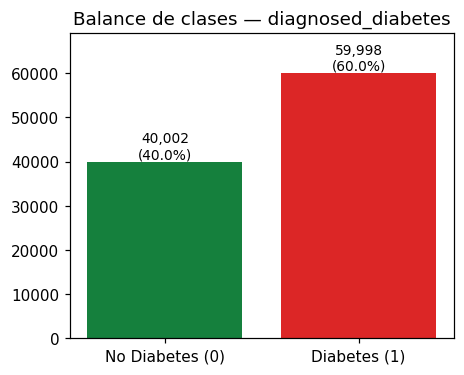

In [3]:
print('Objetivo:', audit['target']['name'])
print('Conteos:', audit['target']['counts'])
print('Balance %:', audit['target']['balance_pct'], '| ratio:', audit['target']['imbalance_ratio'])
display(Image(filename=str(config.FIGURES_DIR/'eda'/'class_balance.png')))

### Tipos, cardinalidad y nulos

In [4]:
meta = pd.DataFrame({'dtype': audit['dtypes'], 'cardinalidad': audit['cardinality'], 'nulos': audit['nulls']})
meta

,dtype,cardinalidad,nulos
age,int64,73,0
gender,object,3,0
ethnicity,object,5,0
education_level,object,4,0
income_level,object,5,0
employment_status,object,4,0
smoking_status,object,3,0
alcohol_consumption_per_week,int64,11,0
physical_activity_minutes_per_week,int64,620,0
diet_score,float64,101,0


### Outliers (IQR) de variables numéricas

In [5]:
out = pd.DataFrame(audit['outliers']).T[['n_outliers','pct_outliers','min','max','mean','std']]
out.sort_values('pct_outliers', ascending=False).head(15)

,n_outliers,pct_outliers,min,max,mean,std
family_history_diabetes,21941.0,21.941,0.0,1.0,0.219410,0.413849
cardiovascular_history,7920.0,7.920,0.0,1.0,0.079200,0.270052
physical_activity_minutes_per_week,3199.0,3.199,0.0,833.0,118.911640,84.409662
diabetes_risk_score,914.0,0.914,2.7,67.2,30.222362,9.061505
sleep_hours_per_day,900.0,0.900,3.0,10.0,6.997818,1.094622
heart_rate,855.0,0.855,40.0,105.0,69.632870,8.371954
glucose_fasting,745.0,0.745,60.0,172.0,111.117120,13.595610
bmi,744.0,0.744,15.0,39.2,25.612653,3.586705
diastolic_bp,731.0,0.731,50.0,110.0,75.232490,8.204250
glucose_postprandial,634.0,0.634,70.0,287.0,160.035050,30.935472


### Correlación con el objetivo — primera señal de fuga
Las variables más correlacionadas son **laboratorios diagnósticos** (hba1c, glucosa), lo que anticipa fuga de información si se usan como predictores.

In [6]:
pd.Series(audit['abs_corr_with_target']).head(12).to_frame('|corr| con objetivo')

,|corr| con objetivo
hba1c,0.6794
glucose_postprandial,0.6298
glucose_fasting,0.5109
diabetes_risk_score,0.2773
family_history_diabetes,0.1979
age,0.1377
physical_activity_minutes_per_week,-0.1008
bmi,0.0971
systolic_bp,0.0955
waist_to_hip_ratio,0.0789


### Hallazgos clave
- 100,000 filas × 31 columnas, **sin nulos ni duplicados**.
- Objetivo `diagnosed_diabetes` con balance ~60/40 (ratio 1.5, desbalanceo leve).
- `diabetes_stage` y `diabetes_risk_score` son **proxies del objetivo** (fuga directa).
- `hba1c`, `glucose_*`, `insulin_level` son **criterios diagnósticos** (fuga parcial).